# Otimizadores Adaptativos: Adagrad, Adadelta e Adam

**Statistisches Lernen 2 — FH Kufstein Tirol**

Este notebook explica **passo a passo**, para iniciantes, três otimizadores muito usados em deep learning:

| Otimizador | Ideia central |
|------------|---------------|
| **Adagrad** | Divide o gradiente por uma escala que cresce com o histórico (parâmetros raros recebem passos maiores) |
| **Adadelta** | Corrige o Adagrad: a escala deixa de crescer para sempre |
| **Adam** | Combina momentum + escala adaptativa por parâmetro (o mais usado na prática) |

---

> **Estrutura:** Conceito intuitivo → Matemática passo a passo → Implementação manual (NumPy) → Uso no PyTorch → Comparação visual

---

## Índice

1. [Por que não basta SGD?](#sec1)
2. [Adagrad](#sec2)
3. [Adadelta](#sec3)
4. [Adam](#sec4)
5. [Comparação visual](#sec5)
6. [Como usar no PyTorch (guia prático)](#sec6)
7. [Resumo e quando escolher cada um](#sec7)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

np.random.seed(42)
torch.manual_seed(42)

plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["font.size"] = 11
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch {torch.__version__} | device: {device}")

PyTorch 2.12.0 | device: cpu


---
<a id="sec1"></a>

## 1. Por que não basta SGD?

### 1.1 O que é um otimizador?

Treinar um modelo = encontrar parâmetros $\theta$ que **minimizam** uma função de perda $\mathcal{L}(\theta)$.

O método mais básico é o **Gradient Descent (GD)**:

$$\theta_{t+1} = \theta_t - \eta \, \nabla_\theta \mathcal{L}(\theta_t)$$

onde $\eta$ é a **taxa de aprendizado (learning rate)**.

**Analogia:** você está numa montanha enevoada e quer descer. O gradiente aponta "para cima"; você dá um passo na direção oposta.

### 1.2 O problema do SGD com $\eta$ fixo

No **SGD** (Stochastic Gradient Descent), usamos um mini-batch de dados por passo — mais rápido e ruidoso, mas a mesma ideia.

**Problemas comuns:**

| Problema | O que acontece |
|----------|----------------|
| Gradientes em **escalas diferentes** | Um parâmetro precisa de passos pequenos, outro de passos grandes — um único $\eta$ não serve para todos |
| Gradientes **raros** (ex: NLP) | Features que aparecem pouco recebem poucos updates; precisam de passos maiores quando aparecem |
| $\eta$ muito grande | Oscila ou diverge |
| $\eta$ muito pequeno | Converge devagar ou para |

**Otimizadores adaptativos** ajustam o tamanho do passo **por parâmetro**, usando o histórico de gradientes.

### 1.3 Mini-demo: um único $\eta$ pode ser ruim

Considere a função $f(w_1, w_2) = w_1^2 + 100 \, w_2^2$ (vale estreito em $w_2$). Com $\eta=0.015$, SGD **diverge** em $w_2$; com $\eta=0.005$, converge mas **muito devagar**.

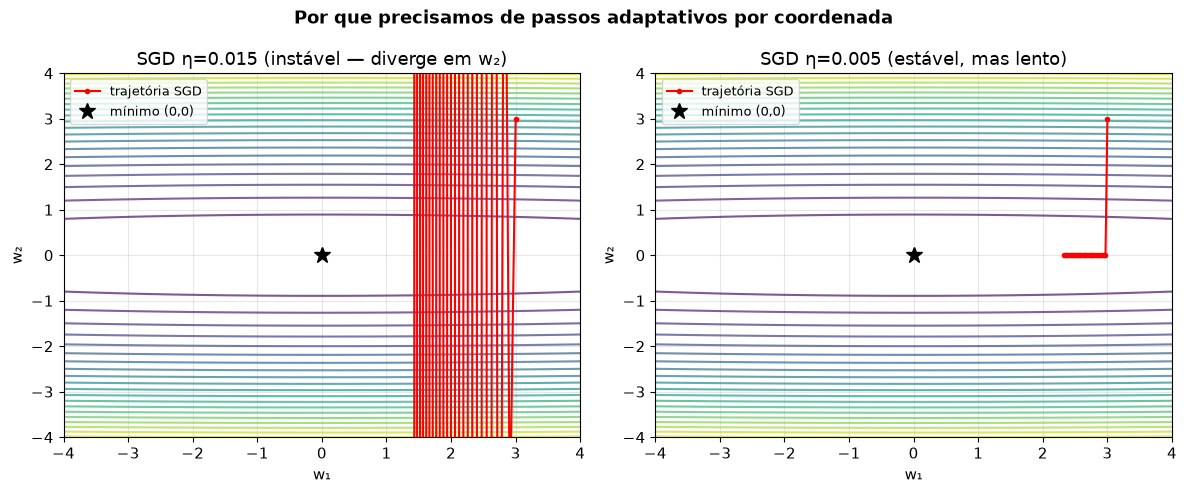

Regra de estabilidade SGD: η < 2/Lᵢ. Aqui L₂=200 → precisa η < 0.01 em w₂.


In [2]:
def sgd_2d(eta, steps=40, w0=(3.0, 3.0)):
    """Gradiente de f(w₁,w₂) = w₁² + 100 w₂². Estável em w₂ só se η < 0.01."""
    w = np.array(w0, dtype=float)
    path = [w.copy()]
    for _ in range(steps):
        grad = np.array([2 * w[0], 200 * w[1]])
        w = w - eta * grad
        path.append(w.copy())
    return np.array(path)

# malha para contornos (reutilizada na Seção 5)
w1 = np.linspace(-4, 4, 100)
w2 = np.linspace(-4, 4, 100)
W1, W2 = np.meshgrid(w1, w2)
Z = W1**2 + 100 * W2**2

def truncar_trajetoria(path, limite=4.0):
    """Corta a trajetória quando sai do quadrado [-limite, limite] (evita bug do matplotlib)."""
    dentro = (np.abs(path[:, 0]) <= limite) & (np.abs(path[:, 1]) <= limite)
    if dentro.all():
        return path
    primeiro_fora = np.argmax(~dentro)
    return path[: max(primeiro_fora + 1, 2)]

fig, axes = plt.subplots(1, 2, figsize=(12, 5), layout="constrained")

for ax, eta, title in zip(
    axes,
    [0.015, 0.005],
    ["SGD η=0.015 (instável — diverge em w₂)", "SGD η=0.005 (estável, mas lento)"],
):
    path = truncar_trajetoria(sgd_2d(eta, steps=25))
    ax.contour(W1, W2, Z, levels=20, cmap="viridis", alpha=0.7)
    ax.plot(path[:, 0], path[:, 1], "ro-", ms=3, lw=1.5, label="trajetória SGD")
    ax.plot(0, 0, "k*", ms=12, label="mínimo (0,0)")
    ax.set_xlim(-4, 4); ax.set_ylim(-4, 4)
    ax.set_xlabel("w₁"); ax.set_ylabel("w₂"); ax.set_title(title)
    ax.legend(fontsize=9)

fig.suptitle("Por que precisamos de passos adaptativos por coordenada", fontweight="bold")
plt.show()

print("Regra de estabilidade SGD: η < 2/Lᵢ. Aqui L₂=200 → precisa η < 0.01 em w₂.")

---
<a id="sec2"></a>

## 2. Adagrad (Adaptive Gradient)

### 2.1 Para que serve?

**Adagrad** (Duchi et al., 2011) acumula o **quadrado** dos gradientes passados e usa isso para **reduzir** o learning rate de parâmetros que já receberam muitos updates grandes.

- Parâmetro com gradientes **grandes e frequentes** → passos **menores**
- Parâmetro com gradientes **raros ou pequenos** → passos **relativamente maiores**

Muito útil em **dados esparsos** (ex: palavras raras em NLP).

### 2.2 Matemática — passo a passo

Para cada parâmetro $i$ no passo $t$:

**Passo 1** — calcule o gradiente $g_t = \nabla_\theta \mathcal{L}(\theta_t)$

**Passo 2** — acumule os quadrados dos gradientes:

$$G_t = G_{t-1} + g_t \odot g_t \quad (\text{soma elemento a elemento})$$

**Passo 3** — atualize os parâmetros:

$$\boxed{\theta_{t+1} = \theta_t - \frac{\eta}{\sqrt{G_t + \epsilon}} \odot g_t}$$

- $\odot$ = multiplicação elemento a elemento
- $\epsilon \approx 10^{-8}$ evita divisão por zero
- $G_t$ **só cresce** → o passo efetivo $\eta / \sqrt{G_t}$ **vai a zero** com muitos passos

### 2.3 Implementação manual (1 parâmetro, NumPy)

Vamos minimizar $f(\theta) = \theta^2$ com $\theta_0 = 3$ e mostrar **cada passo**.

In [3]:
def adagrad_manual(theta0, eta=1.0, eps=1e-8, steps=5):
    theta = float(theta0)
    G = 0.0
    print(f"{'passo':>5} {'θ':>8} {'g':>8} {'G':>10} {'Δθ':>10} {'η_eff':>8}")
    print("-" * 55)
    for t in range(steps):
        g = 2 * theta                     # gradiente de θ²
        G = G + g * g                     # acumula g²
        eta_eff = eta / (np.sqrt(G) + eps)
        delta = eta_eff * g
        theta = theta - delta
        print(f"{t:5d} {theta+delta:8.4f} {g:8.4f} {G:10.4f} {delta:8.4f} {eta_eff:8.4f}")
    return theta

theta_final = adagrad_manual(3.0, eta=1.0, steps=6)
print(f"\nθ final ≈ {theta_final:.6f} (ótimo = 0)")

passo        θ        g          G         Δθ    η_eff
-------------------------------------------------------
    0   3.0000   6.0000    36.0000   1.0000   0.1667
    1   2.0000   4.0000    52.0000   0.5547   0.1387
    2   1.4453   2.8906    60.3556   0.3721   0.1287
    3   1.0732   2.1465    64.9628   0.2663   0.1241
    4   0.8069   1.6138    67.5673   0.1963   0.1217
    5   0.6106   1.2212    69.0585   0.1469   0.1203

θ final ≈ 0.463635 (ótimo = 0)


**Observe:** conforme $G$ cresce, $\eta_{\text{eff}}$ diminui — o algoritmo desacelera automaticamente.

**Limitação:** em treinos longos, $G$ fica enorme → o aprendizado **para cedo demais**. Foi isso que motivou o Adadelta e o Adam.

### 2.4 Adagrad no PyTorch

```python
optimizer = torch.optim.Adagrad(model.parameters(), lr=0.01)
```

**Loop de treino padrão:**

```python
optimizer.zero_grad()   # zera gradientes antigos
loss.backward()         # calcula gradientes
optimizer.step()        # aplica Adagrad
```

Coeficientes estimados: w ≈ 2.269 (real 2.5), b ≈ 1.025 (real 1.0)
Loss final: 0.1239


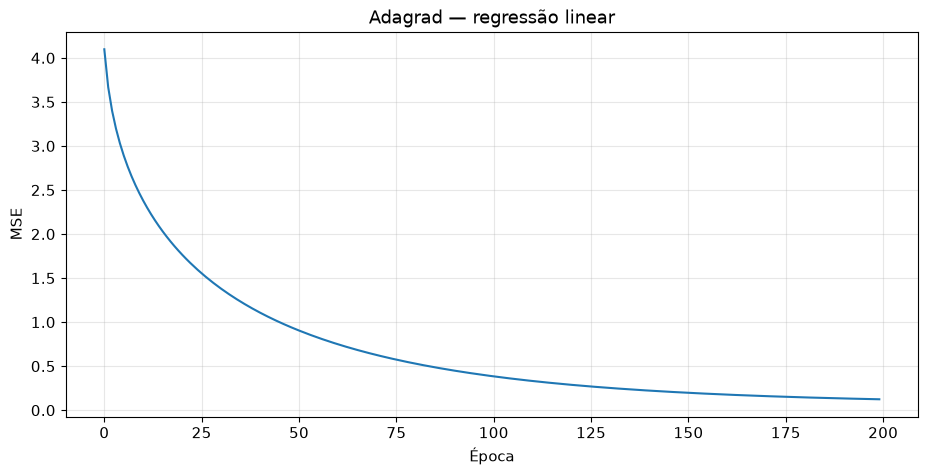

In [4]:
# Exemplo: regressão linear simples com Adagrad
X = torch.randn(100, 1)
y = 2.5 * X + 1.0 + 0.3 * torch.randn(100, 1)

model = nn.Linear(1, 1).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adagrad(model.parameters(), lr=0.1)

losses = []
for epoch in range(200):
    optimizer.zero_grad()
    pred = model(X.to(device))
    loss = criterion(pred, y.to(device))
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

w, b = model.weight.item(), model.bias.item()
print(f"Coeficientes estimados: w ≈ {w:.3f} (real 2.5), b ≈ {b:.3f} (real 1.0)")
print(f"Loss final: {losses[-1]:.4f}")

plt.plot(losses, color="tab:blue")
plt.xlabel("Época"); plt.ylabel("MSE"); plt.title("Adagrad — regressão linear")
plt.show()

---
<a id="sec3"></a>

## 3. Adadelta

### 3.1 Para que serve?

**Adadelta** (Zeiler, 2012) corrige o Adagrad: em vez de acumular **todos** os $g^2$ desde o início, usa uma **média móvel exponencial** — o passo efetivo não vai a zero.

**Vantagem extra:** não precisa escolher $\eta$ manualmente (usa $\eta=1$ por padrão na fórmula original).

### 3.2 Matemática — passo a passo

**Passo 1** — gradiente $g_t$

**Passo 2** — acumule $g^2$ com decaimento (como EMA):

$$E[g^2]_t = \rho \, E[g^2]_{t-1} + (1-\rho) \, g_t^2 \quad (\text{tipicamente } \rho = 0.9)$$

**Passo 3** — acumule também os **quadrados das atualizações** $\Delta\theta$:

$$E[\Delta\theta^2]_t = \rho \, E[\Delta\theta^2]_{t-1} + (1-\rho) \, \Delta\theta_t^2$$

**Passo 4** — calcule a razão RMS (root mean square) e atualize:

$$\boxed{\Delta\theta_t = - \frac{\text{RMS}(\Delta\theta)_{t-1}}{\text{RMS}(g)_t + \epsilon} \odot g_t}$$

$$\theta_{t+1} = \theta_t + \Delta\theta_t$$

**Intuição:** se os gradientes recentes são grandes, o denominador cresce → passo menor. Se as atualizações passadas foram grandes, o numerador compensa — escala adaptativa **estável** no tempo.

### 3.3 Implementação manual (NumPy, 1D)

In [5]:
def adadelta_manual(theta0, rho=0.9, eps=1e-8, steps=8):
    theta = float(theta0)
    Eg2 = 0.0      # E[g²]
    Ed2 = 0.0      # E[Δθ²]
    print(f"{'passo':>5} {'θ':>8} {'g':>8} {'Δθ':>10}")
    print("-" * 40)
    for t in range(steps):
        g = 2 * theta
        Eg2 = rho * Eg2 + (1 - rho) * g * g
        delta = -np.sqrt(Ed2 + eps) / (np.sqrt(Eg2) + eps) * g
        Ed2 = rho * Ed2 + (1 - rho) * delta * delta
        theta = theta + delta
        print(f"{t:5d} {theta:8.4f} {g:8.4f} {delta:10.4f}")
    return theta

print("Adadelta em f(θ) = θ², θ₀ = 3:")
theta_ad = adadelta_manual(3.0, steps=10)
print(f"\nθ final ≈ {theta_ad:.6f}")

Adadelta em f(θ) = θ², θ₀ = 3:
passo        θ        g         Δθ
----------------------------------------
    0   2.9997   6.0000    -0.0003
    1   2.9994   5.9994    -0.0003
    2   2.9990   5.9987    -0.0003
    3   2.9987   5.9981    -0.0003
    4   2.9984   5.9974    -0.0003
    5   2.9980   5.9967    -0.0003
    6   2.9977   5.9960    -0.0003
    7   2.9973   5.9953    -0.0003
    8   2.9970   5.9947    -0.0003
    9   2.9966   5.9940    -0.0004

θ final ≈ 2.996626


### 3.4 Adadelta no PyTorch

```python
optimizer = torch.optim.Adadelta(model.parameters(), lr=1.0, rho=0.9, eps=1e-6)
```

> **Nota:** no PyTorch, `lr` escala o update final; o valor padrão é `1.0` (diferente de SGD/Adam).

In [6]:
model = nn.Linear(1, 1).to(device)
optimizer = torch.optim.Adadelta(model.parameters(), lr=1.0)
criterion = nn.MSELoss()

losses_ad = []
for _ in range(200):
    optimizer.zero_grad()
    pred = model(X.to(device))
    loss = criterion(pred, y.to(device))
    loss.backward()
    optimizer.step()
    losses_ad.append(loss.item())

print(f"Adadelta — w ≈ {model.weight.item():.3f}, b ≈ {model.bias.item():.3f}, loss = {losses_ad[-1]:.4f}")

Adadelta — w ≈ 1.305, b ≈ 0.875, loss = 1.5078


---
<a id="sec4"></a>

## 4. Adam (Adaptive Moment Estimation)

### 4.1 Para que serve?

**Adam** (Kingma & Ba, 2015) é o otimizador **mais popular** em deep learning. Combina duas ideias:

1. **Momentum** — média móvel do gradiente (direção "suavizada")
2. **RMSprop/Adagrad-like** — média móvel de $g^2$ (escala adaptativa por parâmetro)

Funciona bem **out-of-the-box** com hiperparâmetros padrão (`lr=0.001`, `betas=(0.9, 0.999)`).

### 4.2 Matemática — passo a passo

Hiperparâmetros: $\eta$ (lr), $\beta_1=0.9$, $\beta_2=0.999$, $\epsilon=10^{-8}$

**Passo 1** — gradiente $g_t$

**Passo 2** — 1º momento (média do gradiente):

$$m_t = \beta_1 m_{t-1} + (1-\beta_1) g_t$$

**Passo 3** — 2º momento (média de $g^2$):

$$v_t = \beta_2 v_{t-1} + (1-\beta_2) g_t^2$$

**Passo 4** — correção de viés (no início, $m_t$ e $v_t$ são enviesados para zero):

$$\hat{m}_t = \frac{m_t}{1 - \beta_1^t}, \quad \hat{v}_t = \frac{v_t}{1 - \beta_2^t}$$

**Passo 5** — update:

$$\boxed{\theta_{t+1} = \theta_t - \eta \, \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon}}$$

### 4.3 Implementação manual com tabela de passos

In [7]:
def adam_manual(theta0, eta=0.1, beta1=0.9, beta2=0.999, eps=1e-8, steps=6):
    theta = float(theta0)
    m, v = 0.0, 0.0
    print(f"{'t':>3} {'θ':>8} {'g':>8} {'m̂':>8} {'v̂':>10} {'Δθ':>8}")
    print("-" * 52)
    for t in range(1, steps + 1):
        g = 2 * theta
        m = beta1 * m + (1 - beta1) * g
        v = beta2 * v + (1 - beta2) * g * g
        m_hat = m / (1 - beta1**t)
        v_hat = v / (1 - beta2**t)
        delta = eta * m_hat / (np.sqrt(v_hat) + eps)
        theta = theta - delta
        print(f"{t:3d} {theta+delta:8.4f} {g:8.4f} {m_hat:8.4f} {v_hat:10.4f} {delta:8.4f}")
    return theta

print("Adam em f(θ) = θ², θ₀ = 3:")
theta_adam = adam_manual(3.0, eta=0.5, steps=8)
print(f"\nθ final ≈ {theta_adam:.6f}")

Adam em f(θ) = θ², θ₀ = 3:
  t        θ        g       m̂         v̂       Δθ
----------------------------------------------------
  1   3.0000   6.0000   6.0000    36.0000   0.5000
  2   2.5000   5.0000   5.4737    30.4972   0.4956
  3   2.0044   4.0088   4.9331    25.6836   0.4867
  4   1.5177   3.0354   4.3813    21.5599   0.4718
  5   1.0459   2.0918   3.8222    18.1162   0.4490
  6   0.5969   1.1938   3.2613    15.3274   0.4165
  7   0.1804   0.3608   2.7053    13.1499   0.3730
  8  -0.1926  -0.3852   2.1627    11.5190   0.3186

θ final ≈ -0.511222


**Por que a correção de viés?** No passo $t=1$, $m_1 = 0.1 \, g_1$ — muito menor que $g_1$. Dividir por $(1-\beta_1^t)$ compensa esse "cold start".

### 4.4 Adam no PyTorch

Adam — w ≈ 1.602, b ≈ 0.682, loss = 1.0132


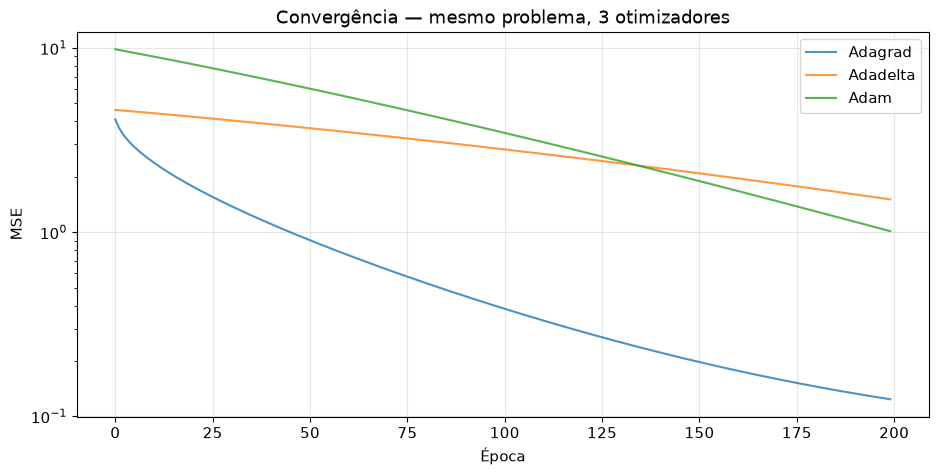

In [8]:
model = nn.Linear(1, 1).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, betas=(0.9, 0.999))
criterion = nn.MSELoss()

losses_adam = []
for _ in range(200):
    optimizer.zero_grad()
    pred = model(X.to(device))
    loss = criterion(pred, y.to(device))
    loss.backward()
    optimizer.step()
    losses_adam.append(loss.item())

print(f"Adam — w ≈ {model.weight.item():.3f}, b ≈ {model.bias.item():.3f}, loss = {losses_adam[-1]:.4f}")

plt.plot(losses, label="Adagrad", alpha=0.8)
plt.plot(losses_ad, label="Adadelta", alpha=0.8)
plt.plot(losses_adam, label="Adam", alpha=0.8)
plt.xlabel("Época"); plt.ylabel("MSE"); plt.title("Convergência — mesmo problema, 3 otimizadores")
plt.legend(); plt.yscale("log")
plt.show()

---
<a id="sec5"></a>

## 5. Comparação visual — vale estreito

Treinamos os 4 métodos (SGD, Adagrad, Adadelta, Adam) na mesma função $f(w_1,w_2) = w_1^2 + 100 w_2^2$ e comparamos as **trajetórias** no plano.

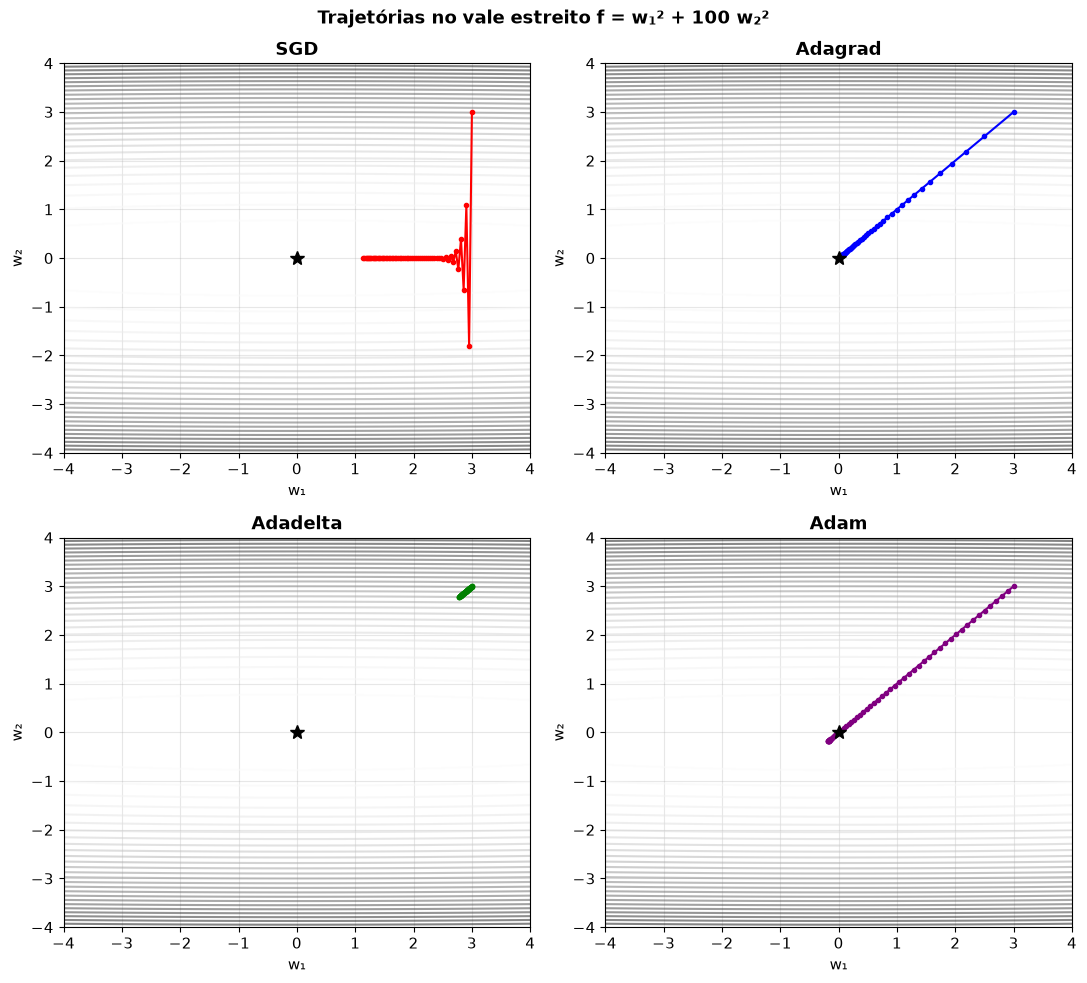

In [9]:
def run_optimizer(name, steps=60, w0=(3.0, 3.0)):
    w = torch.tensor(w0, dtype=torch.float32, requires_grad=True)
    if name == "SGD":
        opt = torch.optim.SGD([w], lr=0.008)
    elif name == "Adagrad":
        opt = torch.optim.Adagrad([w], lr=0.5)
    elif name == "Adadelta":
        opt = torch.optim.Adadelta([w], lr=1.0)
    elif name == "Adam":
        opt = torch.optim.Adam([w], lr=0.1)
    else:
        raise ValueError(name)

    path = [w.detach().numpy().copy()]
    for _ in range(steps):
        opt.zero_grad()
        loss = w[0]**2 + 100 * w[1]**2
        loss.backward()
        opt.step()
        path.append(w.detach().numpy().copy())
    return np.array(path)

fig, axes = plt.subplots(2, 2, figsize=(11, 10), layout="constrained")
names = ["SGD", "Adagrad", "Adadelta", "Adam"]
colors = ["red", "blue", "green", "purple"]

for ax, name, color in zip(axes.flat, names, colors):
    path = truncar_trajetoria(run_optimizer(name))
    ax.contour(W1, W2, Z, levels=30, cmap="Greys", alpha=0.5)
    ax.plot(path[:, 0], path[:, 1], "o-", color=color, ms=3, lw=1.5)
    ax.plot(0, 0, "k*", ms=10)
    ax.set_title(name, fontweight="bold")
    ax.set_xlabel("w₁"); ax.set_ylabel("w₂")
    ax.set_xlim(-4, 4); ax.set_ylim(-4, 4)

fig.suptitle("Trajetórias no vale estreito f = w₁² + 100 w₂²", fontweight="bold")
plt.show()

**Leitura:** métodos adaptativos (Adagrad, Adadelta, Adam) costumam chegar mais rápido ao mínimo neste vale assimétrico, enquanto SGD com $\eta$ fixo oscila ou converge devagar.

---
<a id="sec6"></a>

## 6. Como usar no PyTorch — guia prático

### 6.1 Template completo de treino

```python
import torch
import torch.nn as nn

model = MeuModelo()

# Escolha UM otimizador:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)          # padrão DL
# optimizer = torch.optim.Adagrad(model.parameters(), lr=0.01)      # dados esparsos
# optimizer = torch.optim.Adadelta(model.parameters(), lr=1.0)      # sem tunar lr
# optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)  # baseline

criterion = nn.CrossEntropyLoss()  # ou MSELoss, etc.

for epoch in range(num_epochs):
    for x_batch, y_batch in train_loader:
        optimizer.zero_grad()           # 1. limpa gradientes
        outputs = model(x_batch)        # 2. forward
        loss = criterion(outputs, y_batch)
        loss.backward()                 # 3. backward (gradientes)
        optimizer.step()                # 4. update dos pesos
```

### 6.2 Hiperparâmetros comuns

| Otimizador | Parâmetro | Valor típico | O que faz |
|------------|-----------|--------------|----------|
| **Adam** | `lr` | `1e-3` a `3e-4` | taxa de aprendizado global |
| | `betas` | `(0.9, 0.999)` | decaimento dos momentos |
| | `weight_decay` | `0` ou `1e-4` | L2 (regularização) |
| **Adagrad** | `lr` | `0.01` – `0.1` | escala inicial (desacelera com o tempo) |
| **Adadelta** | `lr` | `1.0` | fator de escala final |
| | `rho` | `0.9` | decaimento da média móvel |

### 6.3 Exemplo: classificador MLP no MNIST subset

In [10]:
from torchvision import datasets, transforms

# Subset pequeno para demo rápida (~30s CPU)
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])
train_ds = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_ds  = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

n_train, n_test = 2000, 500
train_loader = DataLoader(train_ds, batch_size=64, sampler=torch.utils.data.SubsetRandomSampler(range(n_train)))
test_loader  = DataLoader(test_ds,  batch_size=256, sampler=torch.utils.data.SubsetRandomSampler(range(n_test)))

class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 128),
            nn.ReLU(),
            nn.Linear(128, 10),
        )
    def forward(self, x):
        return self.net(x)

def train_eval(optimizer_name, epochs=5, lr=None):
    model = MLP().to(device)
    if optimizer_name == "Adam":
        opt = torch.optim.Adam(model.parameters(), lr=lr or 0.001)
    elif optimizer_name == "Adagrad":
        opt = torch.optim.Adagrad(model.parameters(), lr=lr or 0.01)
    elif optimizer_name == "Adadelta":
        opt = torch.optim.Adadelta(model.parameters(), lr=lr or 1.0)
    crit = nn.CrossEntropyLoss()

    for _ in range(epochs):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            loss = crit(model(xb), yb)
            loss.backward()
            opt.step()

    model.eval()
    correct = total = 0
    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)
            preds = model(xb).argmax(dim=1)
            correct += (preds == yb).sum().item()
            total += yb.size(0)
    return correct / total

results = {name: train_eval(name) for name in ["Adam", "Adagrad", "Adadelta"]}
print("Acurácia no teste (5 épocas, subset MNIST):")
for name, acc in results.items():
    print(f"  {name:10s}  {acc:.1%}")


  0%|          | 0.00/9.91M [00:00<?, ?B/s]


  0%|          | 32.8k/9.91M [00:00<00:30, 320kB/s]


  1%|          | 98.3k/9.91M [00:00<00:21, 460kB/s]


  2%|▏         | 164k/9.91M [00:00<00:20, 469kB/s] 


  4%|▎         | 360k/9.91M [00:00<00:10, 915kB/s]

...


 64%|██████▎   | 1.05M/1.65M [00:00<00:00, 2.14MB/s]


100%|██████████| 1.65M/1.65M [00:00<00:00, 2.21MB/s]


  0%|          | 0.00/4.54k [00:00<?, ?B/s]


100%|██████████| 4.54k/4.54k [00:00<00:00, 4.92MB/s]

Acurácia no teste (5 épocas, subset MNIST):
  Adam        89.6%
  Adagrad     89.6%
  Adadelta    90.6%


> **Dica:** Adam costuma ser o ponto de partida. Se overfit, tente `weight_decay=1e-4`. Se treino instável, reduza `lr` (ex: `3e-4`).

---
<a id="sec7"></a>

## 7. Resumo — quando usar cada um?

| Otimizador | Use quando… | Evite quando… |
|------------|-------------|---------------|
| **Adagrad** | Dados **esparsos** (NLP clássico, features raras) | Treino **muito longo** (lr efetivo → 0) |
| **Adadelta** | Quer adaptação sem tunar lr; sequências médias | Precisa do estado da arte em visão/NLP moderno |
| **Adam** | **Default** para redes neurais, visão, NLP, PyTorch | Problemas muito específicos onde SGD+momentum ainda vence (alguns papers de generalização) |

### Linha do tempo (simplificada)

```
SGD → Adagrad (2011) → RMSprop → Adadelta (2012) → Adam (2015) → AdamW (2019)
```

### Checklist do iniciante

1. Comece com **`torch.optim.Adam(model.parameters(), lr=1e-3)`**
2. Sempre: `zero_grad()` → `backward()` → `step()`
3. Plote a **loss por época** — se não cair, ajuste `lr`
4. Para entender o que acontece por baixo, releia as implementações manuais nas Seções 2–4

---

### Referências

- Duchi et al. (2011) — *Adaptive Subgradient Methods for Online Learning and Stochastic Optimization* (Adagrad)
- Zeiler (2012) — *ADADELTA: An Adaptive Learning Rate Method* (Adadelta)
- Kingma & Ba (2015) — *Adam: A Method for Stochastic Optimization* (Adam)
- [PyTorch Optimizer docs](https://pytorch.org/docs/stable/optim.html)